Question 1: Load Dataset and Display Basic Information

In [3]:
import pandas as pd

df = pd.read_csv("zomato.csv")

print(df.head())

print("\nDataset Info\n")

print(df.info())

print("\nStatistical Summary\n")

print(df.describe())

  restaurant_name  cost  rating       cuisine   location
0     Spice Villa   500     4.3  North Indian  Ahmedabad
1       Pizza Hub   800     4.5       Italian  Ahmedabad
2    Burger Point   350     3.8     Fast Food      Surat
3     South Treat   450     4.1  South Indian   Vadodara
4   Royal Biryani   600     4.4       Mughlai  Ahmedabad

Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  20 non-null     object 
 1   cost             20 non-null     int64  
 2   rating           20 non-null     float64
 3   cuisine          20 non-null     object 
 4   location         20 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 932.0+ bytes
None

Statistical Summary

              cost     rating
count    20.000000  20.000000
mean    577.500000   4.170000
std     268.756885   0.327832
min  

Question 2: Missing Values and Outlier Handling

Missing Values
restaurant_name    0
cost               0
rating             0
cuisine            0
location           0
dtype: int64


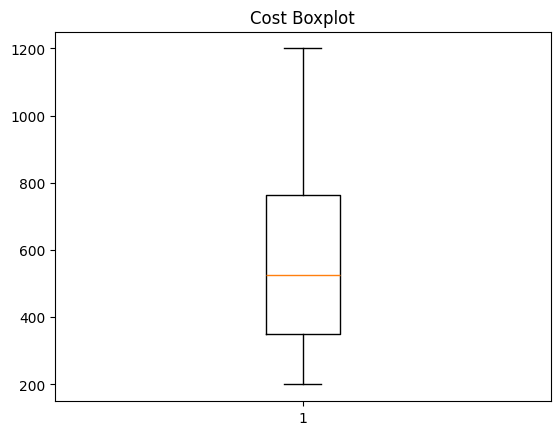

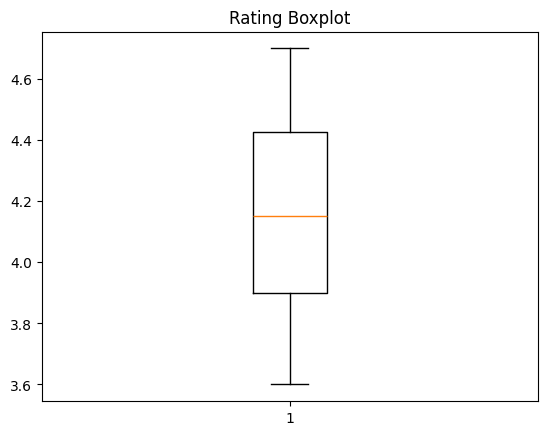

Outliers Removed


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

print("Missing Values")

print(df.isnull().sum())

df["cost"] = df["cost"].fillna(
    df["cost"].median()
)

df["rating"] = df["rating"].fillna(
    df["rating"].median()
)

plt.boxplot(df["cost"])

plt.title("Cost Boxplot")

plt.show()

plt.boxplot(df["rating"])

plt.title("Rating Boxplot")

plt.show()

Q1 = df["cost"].quantile(0.25)

Q3 = df["cost"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df["cost"] >= lower)
    &
    (df["cost"] <= upper)
]

Q1 = df["rating"].quantile(0.25)

Q3 = df["rating"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df["rating"] >= lower)
    &
    (df["rating"] <= upper)
]

print("Outliers Removed")

Question 3: Encoding and Scaling

In [5]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("zomato.csv")

label_encoder = LabelEncoder()

df["cuisine"] = label_encoder.fit_transform(
    df["cuisine"]
)

df["location"] = label_encoder.fit_transform(
    df["location"]
)

scaler = StandardScaler()

df[["cost","rating"]] = scaler.fit_transform(
    df[["cost","rating"]]
)

print(df.head())

  restaurant_name      cost    rating  cuisine  location
0     Spice Villa -0.295856  0.406846        7         0
1       Pizza Hub  0.849393  1.032764        5         0
2    Burger Point -0.868480 -1.157947        4         2
3     South Treat -0.486731 -0.219071        8         3
4   Royal Biryani  0.085894  0.719805        6         0


Question 4: Logistic Regression vs Random Forest

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score

df = pd.read_csv("zomato.csv")

label_encoder = LabelEncoder()

df["cuisine"] = label_encoder.fit_transform(
    df["cuisine"]
)

df["location"] = label_encoder.fit_transform(
    df["location"]
)

df["target"] = (
    df["rating"] > 4.0
).astype(int)

X = df[
    ["cost","cuisine","location"]
]

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_prob = lr.predict_proba(
    X_test
)[:,1]

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print(
    "Logistic Regression ROC-AUC:",
    lr_auc
)

print(
    "Random Forest ROC-AUC:",
    rf_auc
)

if rf_auc > lr_auc:
    print(
        "Random Forest Performed Better"
    )
else:
    print(
        "Logistic Regression Performed Better"
    )

Logistic Regression ROC-AUC: nan
Random Forest ROC-AUC: nan
Logistic Regression Performed Better


c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
